# Clean V2 RidgeLinUCB Evaluation

This notebook is the active RidgeLinUCB benchmark for the cleaned V2 preprocessing flow. It evaluates only the feature sets that survived the previous broad feature-engineering round:

1. `v2_pharmacogenetic_augmented_regression_hw`
2. `v2_strict_regression_hw_full_dummies`
3. `v2_strict_knn_hw_full_dummies`

Retired exploratory feature sets are intentionally not run here: group-median height/weight, drop-first dummies, expanded target-INR/indication, and IWPC-minimal features.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start=None):
    path = Path(start or Path.cwd()).resolve()
    for candidate in [path] + list(path.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root.')


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.bandits.linUCB import RidgeLinUCB
from src.evaluation.feature_set_benchmark import (
    FINAL_FEATURE_SETS,
    FINAL_RIDGE_GRID,
    available_final_feature_sets,
    classwise_metrics,
    confusion_table,
    evaluate_feature_set_grid,
    list_feature_sets,
    load_v2_assets,
    plot_feature_set_accuracy,
    save_benchmark_outputs,
    static_policy_summary,
    summarize_error_metrics,
)

RESULTS_DIR = REPO_ROOT / 'results' / 'v2_feature_set_evaluation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Repo root:', REPO_ROOT)
print('Results dir:', RESULTS_DIR)


Repo root: /Users/dhillo/Garage/codeComplete/full measure/warfarin
Results dir: /Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation


## 1. Load cleaned V2 assets

Run `src/preprocessing/preprocess_v2.ipynb` first. The feature manifest should now contain only the three active feature sets.


In [2]:
df_v2, feature_sets, preprocess_output_dir = load_v2_assets(REPO_ROOT)
feature_set_names = available_final_feature_sets(feature_sets, FINAL_FEATURE_SETS)

print('V2 modeling table:', df_v2.shape)
print('V2 preprocessing output:', preprocess_output_dir)
print('Active feature sets:', feature_set_names)

list_feature_sets(feature_sets)


V2 modeling table: (5528, 253)
V2 preprocessing output: /Users/dhillo/Garage/codeComplete/full measure/warfarin/output/preprocess_v2
Active feature sets: ['v2_pharmacogenetic_augmented_regression_hw', 'v2_strict_regression_hw_full_dummies', 'v2_strict_knn_hw_full_dummies']


,feature_set,n_features
0,v2_pharmacogenetic_augmented_regression_hw,217
1,v2_strict_regression_hw_full_dummies,213
2,v2_strict_knn_hw_full_dummies,213
3,v2_expanded_regression_hw_with_indication_targ...,235
4,v2_iwpc_minimal_regression_hw,26
5,v2_strict_group_median_hw_full_dummies,213
6,v2_strict_regression_hw_drop_first,165


## 2. Static baseline checks

These are not bandits, but they are the key reference lines for the project: fixed medium dose, clinical formula, and pharmacogenetic formula.


In [3]:
static_baselines = static_policy_summary(df_v2, feature_set_names)
static_baselines.to_csv(RESULTS_DIR / 'static_baseline_summary.csv', index=False)
static_baselines.sort_values(['feature_set', 'accuracy'], ascending=[True, False])


,feature_set,algorithm,accuracy,fraction_incorrect,n_correct,n_total
2,v2_pharmacogenetic_augmented_regression_hw,Pharmacogenetic Formula (regression_hw),0.691027,0.308973,3820,5528
1,v2_pharmacogenetic_augmented_regression_hw,Clinical Formula (regression_hw),0.639110,0.360890,3533,5528
0,v2_pharmacogenetic_augmented_regression_hw,Fixed Medium Dose,0.611795,0.388205,3382,5528
8,v2_strict_knn_hw_full_dummies,Pharmacogenetic Formula (knn_hw),0.690123,0.309877,3815,5528
7,v2_strict_knn_hw_full_dummies,Clinical Formula (knn_hw),0.640738,0.359262,3542,5528
6,v2_strict_knn_hw_full_dummies,Fixed Medium Dose,0.611795,0.388205,3382,5528
5,v2_strict_regression_hw_full_dummies,Pharmacogenetic Formula (regression_hw),0.691027,0.308973,3820,5528
4,v2_strict_regression_hw_full_dummies,Clinical Formula (regression_hw),0.639110,0.360890,3533,5528
3,v2_strict_regression_hw_full_dummies,Fixed Medium Dose,0.611795,0.388205,3382,5528


## 3. RidgeLinUCB final grid

This compact grid keeps the values that were consistently useful in the previous sweep. It includes `alpha=0` to check whether explicit UCB exploration is helping beyond regularized greedy learning.


In [4]:
SEEDS = range(5)
RIDGE_ALPHAS = FINAL_RIDGE_GRID['alphas']
RIDGE_LAMBDAS = FINAL_RIDGE_GRID['lambda_regs']

ridge_summary, ridge_results, ridge_scale_stats = evaluate_feature_set_grid(
    df=df_v2,
    feature_sets=feature_sets,
    linucb_cls=RidgeLinUCB,
    feature_set_names=feature_set_names,
    alphas=RIDGE_ALPHAS,
    lambda_regs=RIDGE_LAMBDAS,
    seeds=SEEDS,
    standardize=True,
    progress=False,
    verbose=True,
)

ridge_summary.head(15)


RidgeLinUCB feature set: v2_pharmacogenetic_augmented_regression_hw (217 features)
  RidgeLinUCB(alpha=0.0, lambda=5.0)
  RidgeLinUCB(alpha=0.0, lambda=10.0)
  RidgeLinUCB(alpha=0.0, lambda=20.0)
  RidgeLinUCB(alpha=0.01, lambda=5.0)
  RidgeLinUCB(alpha=0.01, lambda=10.0)
  RidgeLinUCB(alpha=0.01, lambda=20.0)
  RidgeLinUCB(alpha=0.025, lambda=5.0)
  RidgeLinUCB(alpha=0.025, lambda=10.0)
  RidgeLinUCB(alpha=0.025, lambda=20.0)
  RidgeLinUCB(alpha=0.05, lambda=5.0)
  RidgeLinUCB(alpha=0.05, lambda=10.0)
  RidgeLinUCB(alpha=0.05, lambda=20.0)
  RidgeLinUCB(alpha=0.1, lambda=5.0)
  RidgeLinUCB(alpha=0.1, lambda=10.0)
  RidgeLinUCB(alpha=0.1, lambda=20.0)
RidgeLinUCB feature set: v2_strict_regression_hw_full_dummies (213 features)
  RidgeLinUCB(alpha=0.0, lambda=5.0)
  RidgeLinUCB(alpha=0.0, lambda=10.0)
  RidgeLinUCB(alpha=0.0, lambda=20.0)
  RidgeLinUCB(alpha=0.01, lambda=5.0)
  RidgeLinUCB(alpha=0.01, lambda=10.0)
  RidgeLinUCB(alpha=0.01, lambda=20.0)
  RidgeLinUCB(alpha=0.025, lambda=

,algorithm,n_runs,final_accuracy_mean,final_accuracy_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,final_fraction_incorrect_std,late_accuracy_mean,late_accuracy_std,final_accuracy_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95,feature_set,alpha,lambda_reg,n_features
13,"RidgeLinUCB(alpha=0.1, lambda=10.0)",5,0.680282,0.003460,1767.4,19.125899,0.319718,0.003460,0.6908,0.024682,0.003033,16.764589,0.003033,0.021635,v2_pharmacogenetic_augmented_regression_hw,0.100,10.0,217
6,"RidgeLinUCB(alpha=0.025, lambda=5.0)",5,0.678726,0.004306,1776.0,23.801260,0.321274,0.004306,0.6936,0.017053,0.003774,20.862725,0.003774,0.014947,v2_pharmacogenetic_augmented_regression_hw,0.025,5.0,217
10,"RidgeLinUCB(alpha=0.05, lambda=10.0)",5,0.677605,0.005259,1782.2,29.072324,0.322395,0.005259,0.6920,0.025140,0.004610,25.483015,0.004610,0.022036,v2_pharmacogenetic_augmented_regression_hw,0.050,10.0,217
12,"RidgeLinUCB(alpha=0.1, lambda=5.0)",5,0.677496,0.002032,1782.8,11.233877,0.322504,0.002032,0.6928,0.018794,0.001781,9.846928,0.001781,0.016473,v2_pharmacogenetic_augmented_regression_hw,0.100,5.0,217
0,"RidgeLinUCB(alpha=0.0, lambda=5.0)",5,0.677135,0.002715,1784.8,15.006665,0.322865,0.002715,0.6920,0.024536,0.002380,13.153922,0.002380,0.021506,v2_pharmacogenetic_augmented_regression_hw,0.000,5.0,217
9,"RidgeLinUCB(alpha=0.05, lambda=5.0)",5,0.676302,0.003514,1789.4,19.424212,0.323698,0.003514,0.6936,0.018407,0.003080,17.026072,0.003080,0.016134,v2_pharmacogenetic_augmented_regression_hw,0.050,5.0,217
3,"RidgeLinUCB(alpha=0.01, lambda=5.0)",5,0.675615,0.003853,1793.2,21.300235,0.324385,0.003853,0.6924,0.024633,0.003377,18.670479,0.003377,0.021592,v2_pharmacogenetic_augmented_regression_hw,0.010,5.0,217
1,"RidgeLinUCB(alpha=0.0, lambda=10.0)",5,0.674457,0.004290,1799.6,23.712866,0.325543,0.004290,0.6868,0.021005,0.003760,20.785243,0.003760,0.018411,v2_pharmacogenetic_augmented_regression_hw,0.000,10.0,217
2,"RidgeLinUCB(alpha=0.0, lambda=20.0)",5,0.673191,0.003386,1806.6,18.716303,0.326809,0.003386,0.6860,0.024000,0.002968,16.405563,0.002968,0.021037,v2_pharmacogenetic_augmented_regression_hw,0.000,20.0,217
7,"RidgeLinUCB(alpha=0.025, lambda=10.0)",5,0.671889,0.006415,1813.8,35.464066,0.328111,0.006415,0.6868,0.022917,0.005623,31.085625,0.005623,0.020088,v2_pharmacogenetic_augmented_regression_hw,0.025,10.0,217


## 4. Save metrics

The saved files include leaderboard, step-level trajectories, class-wise metrics, severe/one-step error summaries, and confusion matrices.


In [5]:
ridge_error_summary = summarize_error_metrics(ridge_results)
ridge_classwise = classwise_metrics(ridge_results)
ridge_confusion_true = confusion_table(ridge_results, normalize='true')
ridge_confusion_counts = confusion_table(ridge_results, normalize=None)

ridge_summary_with_stage = ridge_summary.copy()
ridge_summary_with_stage['stage'] = 'clean_final_grid'

written = save_benchmark_outputs(
    RESULTS_DIR,
    combined_feature_set_leaderboard=ridge_summary_with_stage,
    ridge_feature_set_step_results=ridge_results,
    ridge_feature_set_scale_stats=ridge_scale_stats,
    ridge_feature_set_error_summary=ridge_error_summary,
    ridge_feature_set_classwise=ridge_classwise,
    ridge_feature_set_confusion_true_normalized=ridge_confusion_true,
    ridge_feature_set_confusion_counts=ridge_confusion_counts,
    static_baseline_summary=static_baselines,
)
written


{'combined_feature_set_leaderboard': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/combined_feature_set_leaderboard.csv',
 'ridge_feature_set_step_results': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_feature_set_step_results.csv',
 'ridge_feature_set_scale_stats': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_feature_set_scale_stats.csv',
 'ridge_feature_set_error_summary': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_feature_set_error_summary.csv',
 'ridge_feature_set_classwise': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_feature_set_classwise.csv',
 'ridge_feature_set_confusion_true_normalized': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_feature_set_confusion_true_normalized.csv'

## 5. Leaderboard and diagnostics

The first table is the main RidgeLinUCB leaderboard. The second table shows the error profile for the same configurations.


In [6]:
ridge_summary.head(20)


,algorithm,n_runs,final_accuracy_mean,final_accuracy_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,final_fraction_incorrect_std,late_accuracy_mean,late_accuracy_std,final_accuracy_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95,feature_set,alpha,lambda_reg,n_features
13,"RidgeLinUCB(alpha=0.1, lambda=10.0)",5,0.680282,0.003460,1767.4,19.125899,0.319718,0.003460,0.6908,0.024682,0.003033,16.764589,0.003033,0.021635,v2_pharmacogenetic_augmented_regression_hw,0.100,10.0,217
6,"RidgeLinUCB(alpha=0.025, lambda=5.0)",5,0.678726,0.004306,1776.0,23.801260,0.321274,0.004306,0.6936,0.017053,0.003774,20.862725,0.003774,0.014947,v2_pharmacogenetic_augmented_regression_hw,0.025,5.0,217
10,"RidgeLinUCB(alpha=0.05, lambda=10.0)",5,0.677605,0.005259,1782.2,29.072324,0.322395,0.005259,0.6920,0.025140,0.004610,25.483015,0.004610,0.022036,v2_pharmacogenetic_augmented_regression_hw,0.050,10.0,217
12,"RidgeLinUCB(alpha=0.1, lambda=5.0)",5,0.677496,0.002032,1782.8,11.233877,0.322504,0.002032,0.6928,0.018794,0.001781,9.846928,0.001781,0.016473,v2_pharmacogenetic_augmented_regression_hw,0.100,5.0,217
0,"RidgeLinUCB(alpha=0.0, lambda=5.0)",5,0.677135,0.002715,1784.8,15.006665,0.322865,0.002715,0.6920,0.024536,0.002380,13.153922,0.002380,0.021506,v2_pharmacogenetic_augmented_regression_hw,0.000,5.0,217
9,"RidgeLinUCB(alpha=0.05, lambda=5.0)",5,0.676302,0.003514,1789.4,19.424212,0.323698,0.003514,0.6936,0.018407,0.003080,17.026072,0.003080,0.016134,v2_pharmacogenetic_augmented_regression_hw,0.050,5.0,217
3,"RidgeLinUCB(alpha=0.01, lambda=5.0)",5,0.675615,0.003853,1793.2,21.300235,0.324385,0.003853,0.6924,0.024633,0.003377,18.670479,0.003377,0.021592,v2_pharmacogenetic_augmented_regression_hw,0.010,5.0,217
1,"RidgeLinUCB(alpha=0.0, lambda=10.0)",5,0.674457,0.004290,1799.6,23.712866,0.325543,0.004290,0.6868,0.021005,0.003760,20.785243,0.003760,0.018411,v2_pharmacogenetic_augmented_regression_hw,0.000,10.0,217
2,"RidgeLinUCB(alpha=0.0, lambda=20.0)",5,0.673191,0.003386,1806.6,18.716303,0.326809,0.003386,0.6860,0.024000,0.002968,16.405563,0.002968,0.021037,v2_pharmacogenetic_augmented_regression_hw,0.000,20.0,217
7,"RidgeLinUCB(alpha=0.025, lambda=10.0)",5,0.671889,0.006415,1813.8,35.464066,0.328111,0.006415,0.6868,0.022917,0.005623,31.085625,0.005623,0.020088,v2_pharmacogenetic_augmented_regression_hw,0.025,10.0,217


In [7]:
ridge_error_summary.head(20)


,feature_set,algorithm,alpha,lambda_reg,n_runs,accuracy_mean,accuracy_std,severe_error_rate_mean,severe_error_rate_std,one_step_error_rate_mean,underdose_rate_mean,overdose_rate_mean,accuracy_ci95,severe_error_rate_ci95
12,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=10.0)",0.100,10.0,5,0.680282,0.003460,0.002677,0.000468,0.317041,0.159298,0.160420,0.003033,0.000410
8,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.025, lambda=5.0)",0.025,5.0,5,0.678726,0.004306,0.002569,0.000268,0.318705,0.163531,0.157742,0.003774,0.000235
9,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.05, lambda=10.0)",0.050,10.0,5,0.677605,0.005259,0.001375,0.000505,0.321020,0.164797,0.157598,0.004610,0.000443
14,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=5.0)",0.100,5.0,5,0.677496,0.002032,0.003763,0.001209,0.318741,0.160311,0.162192,0.001781,0.001060
2,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.0, lambda=5.0)",0.000,5.0,5,0.677135,0.002715,0.002822,0.000621,0.320043,0.164761,0.158104,0.002380,0.000545
11,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.05, lambda=5.0)",0.050,5.0,5,0.676302,0.003514,0.002786,0.000454,0.320912,0.164761,0.158936,0.003080,0.000398
5,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.01, lambda=5.0)",0.010,5.0,5,0.675615,0.003853,0.001990,0.000677,0.322395,0.161397,0.162988,0.003377,0.000593
0,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.0, lambda=10.0)",0.000,10.0,5,0.674457,0.004290,0.002026,0.000432,0.323517,0.175687,0.149855,0.003760,0.000379
1,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.0, lambda=20.0)",0.000,20.0,5,0.673191,0.003386,0.001628,0.000222,0.325181,0.173878,0.152931,0.002968,0.000194
6,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.025, lambda=10.0)",0.025,10.0,5,0.671889,0.006415,0.001411,0.000717,0.326700,0.168234,0.159877,0.005623,0.000628


In [8]:
best = ridge_summary.iloc[0]
best_filter = (
    (ridge_classwise['feature_set'] == best['feature_set'])
    & (ridge_classwise['alpha'] == best['alpha'])
    & (ridge_classwise['lambda_reg'] == best['lambda_reg'])
)
ridge_classwise.loc[best_filter].sort_values('class_id')


,feature_set,algorithm,alpha,lambda_reg,class_id,class_name,n_runs,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,support_mean,recall_ci95,f1_ci95
36,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=10.0)",0.1,10.0,0,low,5,0.674351,0.005360,0.452441,0.019321,0.541319,0.013226,1495.0,0.016935,0.011593
37,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=10.0)",0.1,10.0,1,medium,5,0.686957,0.005205,0.885393,0.009941,0.773602,0.001614,3382.0,0.008714,0.001415
38,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=10.0)",0.1,10.0,2,high,5,0.539495,0.031427,0.137942,0.035420,0.218335,0.047070,651.0,0.031047,0.041258


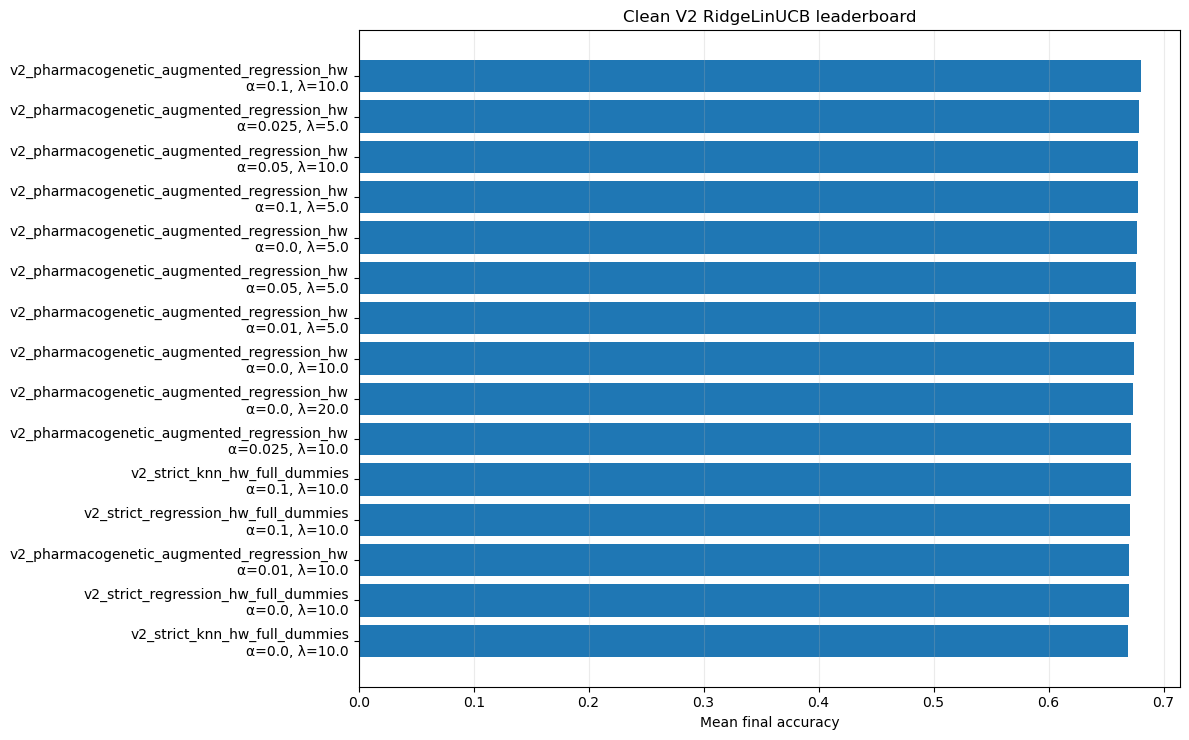

In [9]:
fig, ax = plot_feature_set_accuracy(ridge_summary, top_n=15, title='Clean V2 RidgeLinUCB leaderboard')
fig.savefig(RESULTS_DIR / 'clean_v2_ridge_leaderboard.png', dpi=180, bbox_inches='tight')
plt.show()


## 6. Interpretation checkpoint

Use this notebook to choose the active feature set for advanced algorithms. Based on previous runs, the expected winner is the pharmacogenetic-augmented regression-height/weight feature set, with the strict regression-height/weight set as the clean non-baseline-augmented comparison.
